# **Primera práctica de Aprendizaje Automático**
### **Predicción de subscripción a un producto bancario - Análisis**
Paloma González (*100498978*) y Javier Pastor (*100499039*)

## **0. Pasos previos a la ejecución**

### **Instalación de librerías requeridas para el proyecto:**

In [5]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Fijación de la semilla para el proyecto:**
Utilizaremos el banco de datos 12, puesto que usaremos `ab = 39`, lo que nos da `xx = a+b = 3+9 = 12`. Además, establecemos la semilla con el NIA de uno de los miembros, en este caso `SEMILLA = 100499039`.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
SEMILLA = 100499039
np.random.seed(SEMILLA)
df = pd.read_pickle('bank_ALL/bank_12.pkl')

## **1. EDA simplificado**

#### **Estructura del dataset y tipos de variables:**
   Mediante el uso de `df.info()` y `df.nunique()`, podemos extraer el número total de instancias y variables que forman el conjunto de datos. Asimismo, estas instrucciones nos permiten saber cuáles de estas variables son numéricas (*int64*, *float64*) y cuáles categóricas/ordinales (*object* o *category*).

In [7]:
df.info()
df.nunique()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        10745 non-null  object
 2   marital    11000 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


age            76
job            12
marital         3
education       4
default         2
balance      3783
housing         2
loan            2
contact         3
day            31
month          12
duration     1423
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

#### **Exploración visual de las relaciones multivariantes:**

Para complementar la extracción numérica y hacernos una idea de cómo se relacionan las variables entre sí (y respecto a nuestra variable objetivo *deposit*), generamos las siguientes representaciones gráficas:
- **Pairplot global:** Un análisis bivariante general que nos muestra si existen patrones claros de separabilidad entre las clases 'yes' y 'no' basándonos en las variables numéricas.
- **Pairplot condicionado (sin contacto previo):** Filtramos el dataset para aquellos clientes que no tuvieron contacto previo (`pdays == -1`) generando la misma gráfica. Esto nos ayuda a inferir de un vistazo si el comportamiento de este subgrupo difiere del resto de la base de clientes.
- **Histograma temporal:** Por último, visualizamos la distribución de la característica *day* (día del mes) dentro de dicho subgrupo para encontrar posibles estacionalidades.


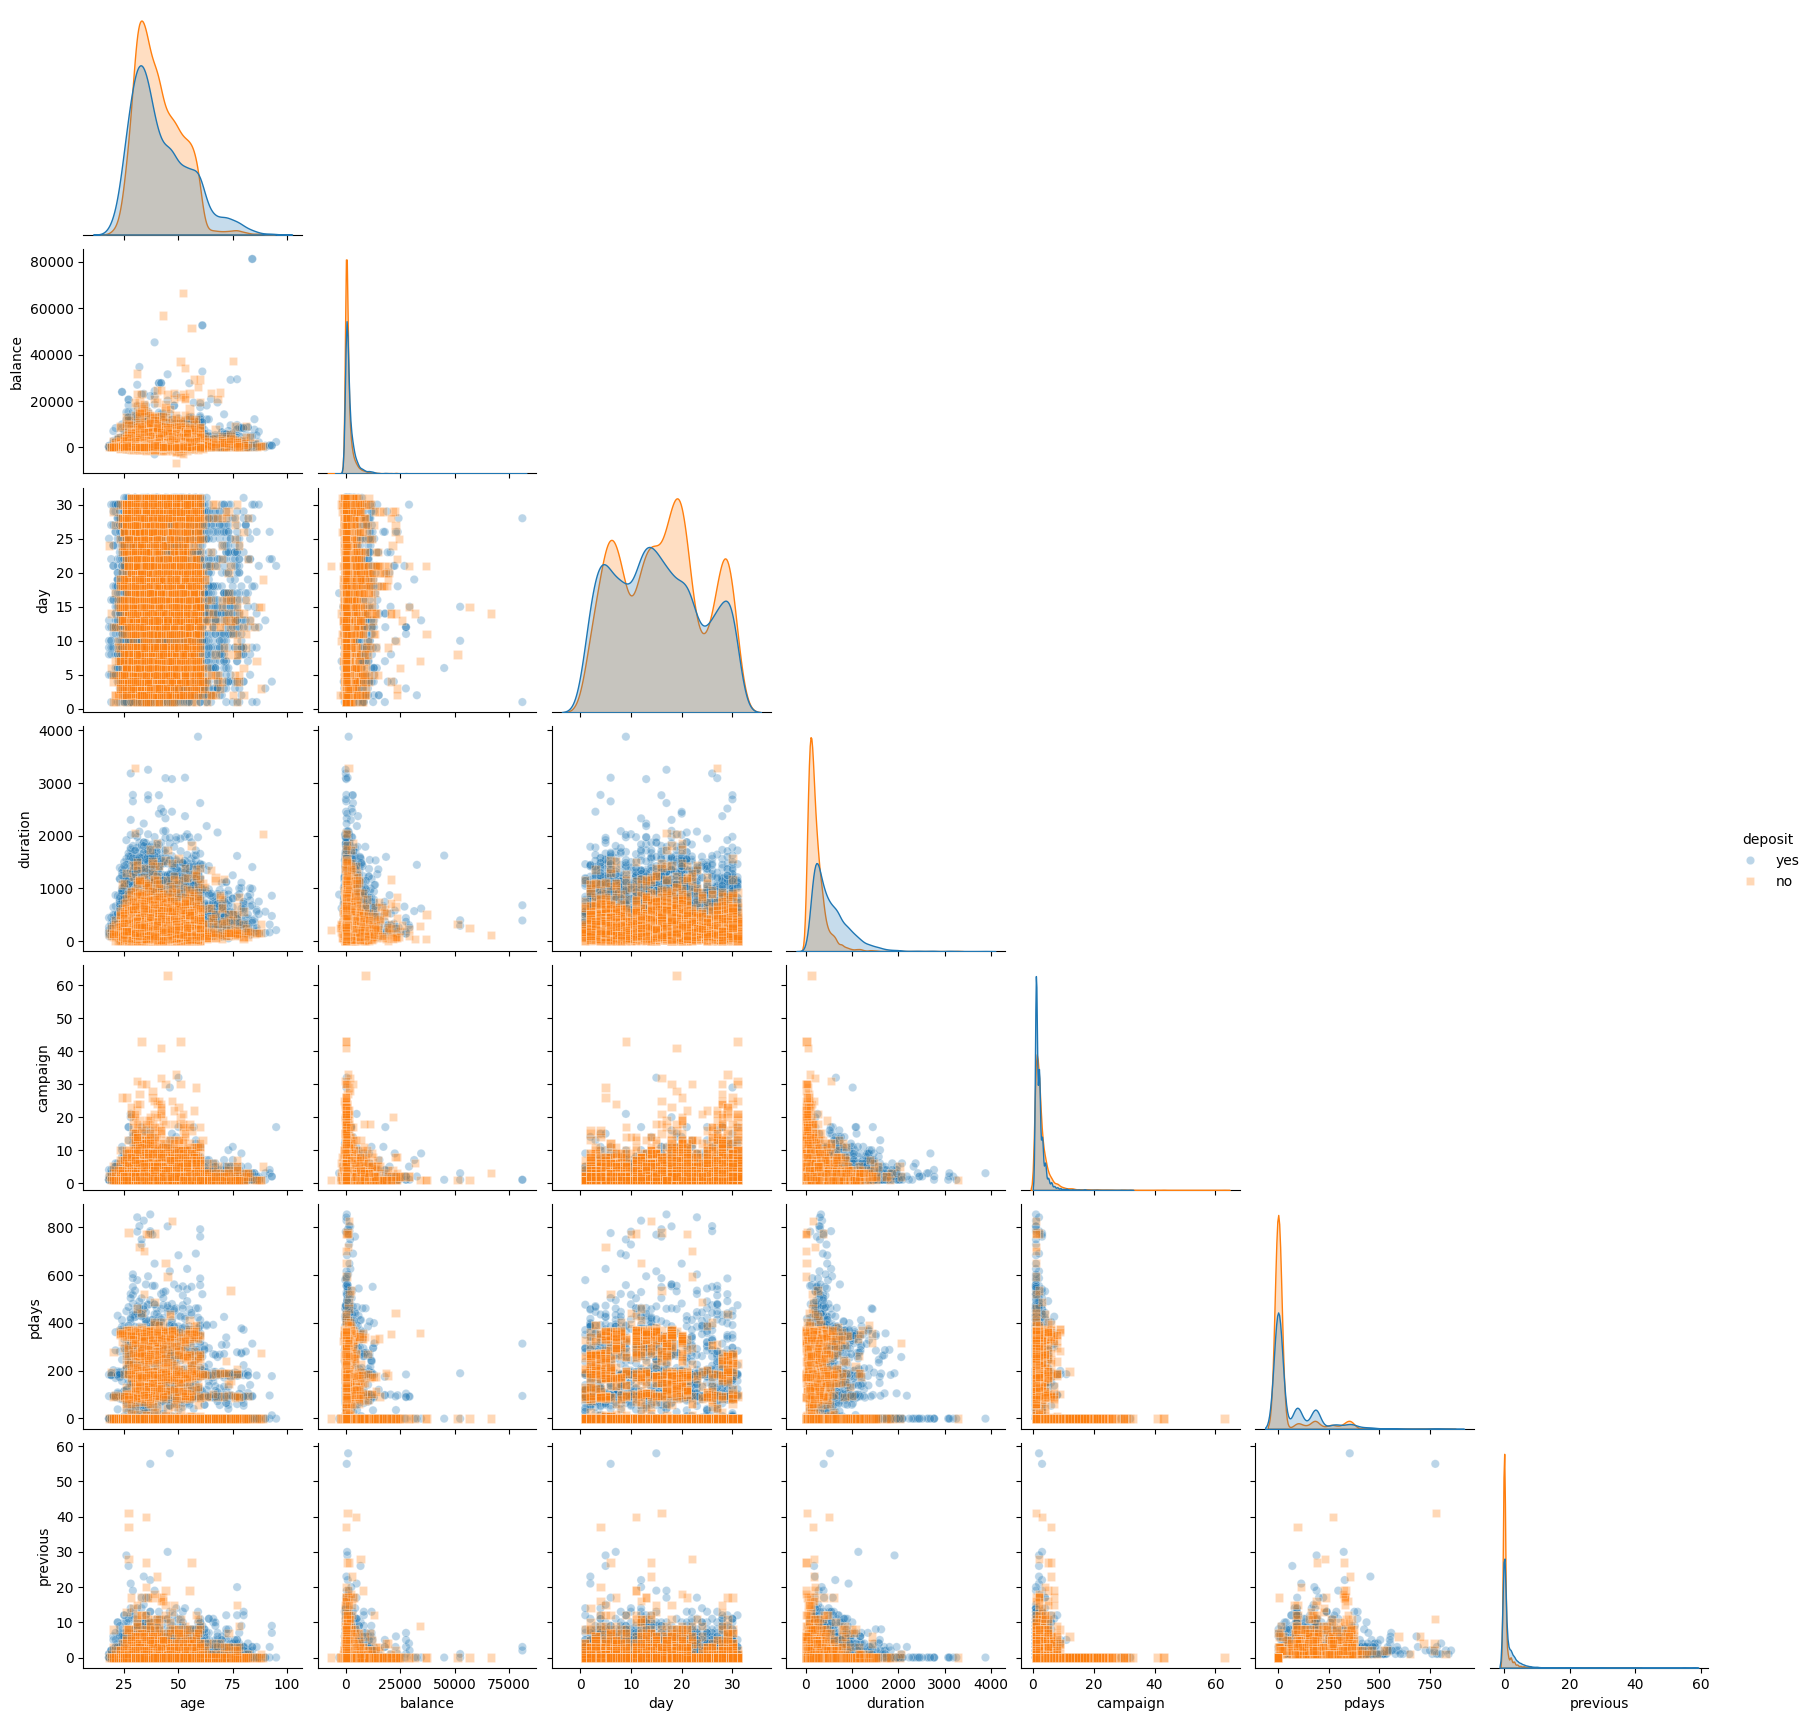

In [8]:
sns.pairplot(df, hue="deposit", markers=["o", "s"], plot_kws={"alpha": 0.3}, corner=True)
plt.show()

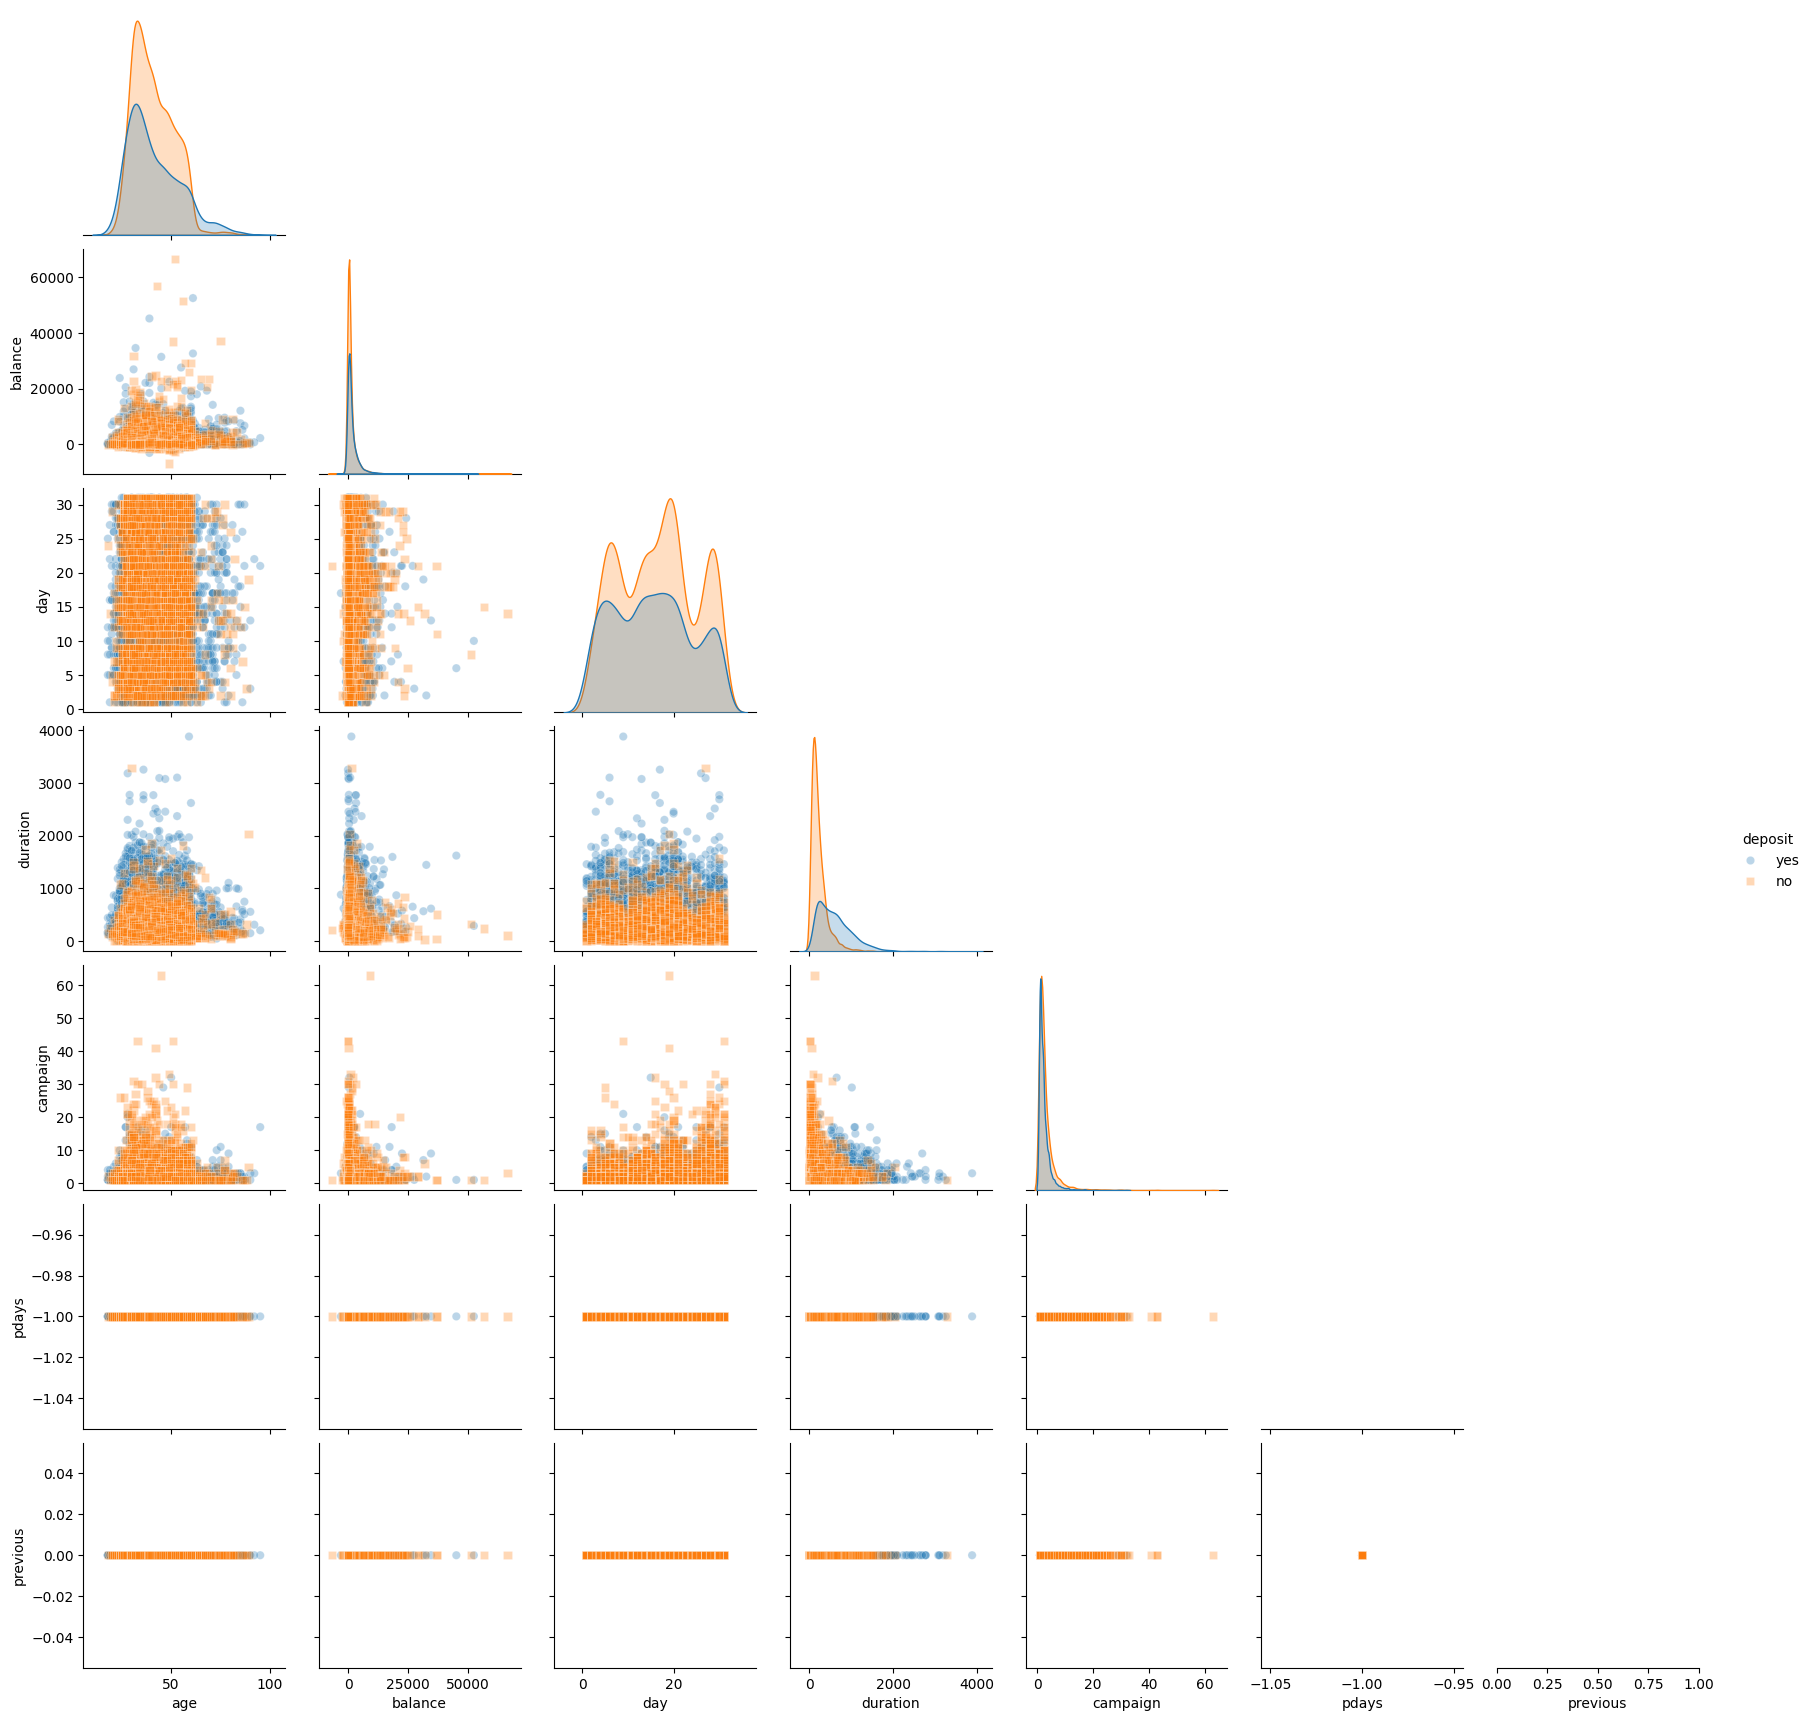

In [9]:
not_previous_contact = df[df['pdays'] == -1]
sns.pairplot(not_previous_contact, hue="deposit", markers=["o", "s"], plot_kws={"alpha": 0.3}, corner=True)
plt.show()

<Axes: >

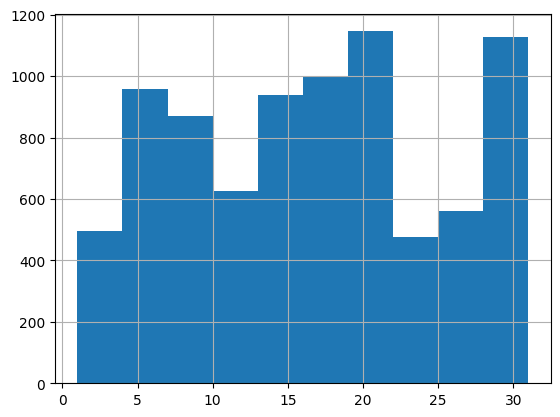

In [10]:
not_previous_contact['day'].hist()

#### **Análisis y preproceso de la variable *pdays***

Realizamos un análisis particular sobre la variable *pdays* (días desde el último contacto en una campaña anterior). Observamos que una gran mayoría de los registros adoptan el valor de `-1`, que actúa como un flag indicando que el cliente **no había sido contactado previamente**, más que como una medida temporal real.

Mantener este valor numérico en los modelos podría introducir un sesgo indeseado. Por ello, procedemos al preprocesamiento en esta misma etapa mediante dos transformaciones:
- **`wasContacted`**: Una variable binaria que indica si hubo contacto (1) o no (0).
- **`contactedLabel`**: Una discretización (*bining*) que agrupa a los clientes según tramos temporales (0: sin contacto, 1: <100 días, 2: <200 días, etc.), capturando así la relevancia del tiempo transcurrido de forma más estructurada.


In [11]:
def pdays_transform(x):
    if x == -1:
        return 0
    else:
        return 1


df["pdays"].map(pdays_transform)
df["wasContacted"] = df["pdays"].map(pdays_transform)

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,wasContacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,0
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,0
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,1


<Axes: xlabel='contactedLabel'>

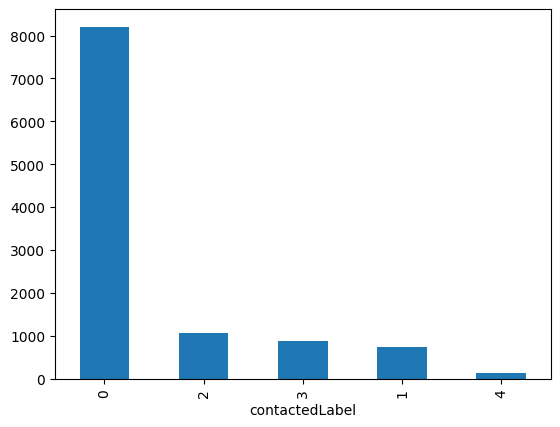

In [12]:
def bin_pdays(x):
    if x == -1:
        return 0
    if x < 100:
        return 1
    elif x < 200:
        return 2
    elif x < 400:
        return 3
    else:
        return 4

df['contactedLabel'] = df['pdays'].map(bin_pdays)
df['contactedLabel'].value_counts(sort=True).plot(kind='bar')

#### **Naturaleza del problema y desbalanceo**

Es fundamental conocer nuestra variable objetivo (*deposit*), la cual determina la suscripción o no al producto. Al ser una variable binaria (*yes* or *no*), el contexto se define como un **problema de clasificación**. Mediante las siguientes sentencias calcularemos su distribución exacta para comprobar el nivel de desbalanceo, un factor crucial para decidir más tarde las estrategias de división (estratificación) y métricas de evaluación.


In [13]:
print("Distribución de la variable objetivo (deposit):")
print(df['deposit'].value_counts())
print("\nPorcentaje de desbalanceo:")
print(df['deposit'].value_counts(normalize=True) * 100)

Distribución de la variable objetivo (deposit):
deposit
no     5780
yes    5220
Name: count, dtype: int64

Porcentaje de desbalanceo:
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64


#### **Comprobaciones estructurales y de calidad de los datos**

Por último, programamos una revisión sistemática del dataset para identificar elementos críticos para el posterior preprocesamiento y entrenamiento:
- **Valores faltantes:** Comprobación automatizada de las variables que contienen elementos nulos.
- **Columnas Constantes e IDs:** Detección de columnas formadas por un solo valor repetido o, por el contrario, que actúan como meros identificadores únicos para cada fila (ambos casos carecen de valor predictivo).
- **Alta Cardinalidad:** Identificación sistemática de las variables categóricas que sobrepasan un umbral de 10 valores únicos, las cuales requerirán atención al aplicar técnicas de codificación para no disparar la dimensionalidad.


In [14]:
print("Valores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Solo muestra las que tienen nulos

# Columnas constantes (1 solo valor) o IDs (tantos valores como filas)
constantes = [col for col in df.columns if df[col].nunique() == 1]
ids = [col for col in df.columns if df[col].nunique() == len(df)]
print(f"\nColumnas constantes: {constantes}")
print(f"Columnas tipo ID: {ids}")

# Alta cardinalidad en variables categóricas (>10 valores únicos)
categoricas = df.select_dtypes(include=['object', 'category']).columns
alta_card = [col for col in categoricas if df[col].nunique() > 10]
print(f"\nVariables categóricas con alta cardinalidad (>10): {alta_card}")

Valores nulos por columna:
job    255
dtype: int64

Columnas constantes: []
Columnas tipo ID: []

Variables categóricas con alta cardinalidad (>10): ['job', 'month']


## **2. División de datos (Holdout)**

#### **Estrategia de evaluación (*outer* e *inner*) y selección de métricas**

Para garantizar que el modelo no solo memorice los datos, sino que generalice bien ante información nueva, hemos definido el siguiente flujo de evaluación:

1. **Evaluación Outer (Holdout):**
   - Siguiendo las instrucciones, dividimos nuestro conjunto original mediante la técnica Holdout: mantendremos **2/3 (66%)** de los datos para entrenamiento (*train*) y **1/3 (33%)** extraído en un compartimento estanco para la evaluación final (*test*).
   - El conjunto de *test* permanecerá totalmente bloqueado durante toda la fase de experimentación. Únicamente lo utilizaremos al final de los respectivos apartados para comprobar de forma genuina el desempeño de nuestros mejores modelos.
   - **Métrica elegida:** Puesto que nuestra variable objetivo presenta un ligero desbalanceo (~47% 'yes' respecto al 52% 'no'), nos centramos especialmente en observar la métrica combinada **F1-Score**, así como el **Recall (Sensibilidad)** de la clase 'yes', pues el objetivo principal de este caso de negocio es no dejar escapar a ningún cliente interesado en suscribir el depósito. También anotaremos la exactitud global (*Accuracy*).

2. **Evaluación Inner (Validación interna):**
   - Puesto que no podemos usar el dataset de prueba (*test*) para ajustar hiperparámetros (HPO), el entrenamiento de cada algoritmo se realizará mediante una estrategia interna de **Validación cruzada** sobre el conjunto de *train*.
   - Usaremos `cv=5` internamente en nuestros procesos de optimización (*GridSearchCV*), lo que asegura que el modelo es validado múltiples veces en particiones distintas del subconjunto de entrenamiento, dotando de mucha más robustez a nuestra decisión de hiperparámetros.

#### **Reestructuración y División del Dataset**

En la siguiente celda procedemos en tres fases:
1. Aislar los atributos dependientes (y) de los predictores (X), eliminando variables ya procesadas en el EDA como *pdays*.
2. Segregar el dataset en conjuntos *train* y *test* utilizando el tamaño definido `test_size=1/3`. Aplicamos el parámetro `stratify=y` para asegurar que la proporción actual de clientes interesados ('yes' / 'no') se mantenga inalterada en ambos conjuntos resultantes.
3. Declarar toda la estandarización y transformación (*SimpleImputer, OneHotEncoder, StandardScaler*) integrándolo todo dentro de un **ColumnTransformer** y un **Pipeline**. Esto evita el riesgo de fuga de información (*Data Leakage*), ya que los escaladores solo "aprenderán" la distribución del *train* (sin haber visto jamás el *test*).


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Separar variables predictoras (X) de la variable objetivo (y)
# Eliminamos 'deposit' (es lo que predecimos) y 'pdays' (usaremos las nuevas que creaste)
X = df.drop(columns=['deposit', 'pdays']) 
y = df['deposit']

# 2. División Train/Test (2/3 para entrenar, 1/3 para testear)
# Usamos stratify=y para que se mantenga el balance ~52/47 en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=1/3, 
    random_state=SEMILLA,
    stratify=y
)

print(f"Filas para Entrenamiento (Train): {X_train.shape[0]}")
print(f"Filas para Evaluación (Test): {X_test.shape[0]}\n")


# PIPELINES

# 1. Identificamos automáticamente qué columnas son números y cuáles texto
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Qué hacer con los números: Solo escalarlos (Estandarización)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# 3. Qué hacer con el texto: Rellenar nulos con el valor más frecuente y hacer One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Juntamos todo en un "Preprocesador" maestro
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocesador configurado con éxito.")

Filas para Entrenamiento (Train): 7333
Filas para Evaluación (Test): 3667

Preprocesador configurado con éxito.


## **3. Métodos básicos: KNN y Árboles**

En esta sección abordaremos por primera vez el modelado predictivo utilizando algoritmos de aprendizaje supervisado de corte clásico. El objetivo principal de este apartado es evaluar enfoques algorítmicos distintos, altamente interpretables, para establecer una sólida línea base (*baseline*) de rendimiento. De esta forma, descubriremos si las características de nuestros clientes permiten trazar un perfil fiable de antemano antes de recurrir a técnicas más costosas matemáticamente.


##### Se trabajarán específicamente dos familias de algoritmos:

- **K-Vecinos más cercanos (KNN):** Este algoritmo asume que instancias demográfica y financieramente similares pertenecerán a la misma clase de interés ("suscribir" o "no suscribir"). Durante su ajuste de hiperparámetros (HPO), prestaremos especial atención no sólo a la cantidad de vecinos de voto (*n_neighbors*), sino a medir directamente el impacto que los distintos métodos de escalado (Standard, MinMax, Robust) provocan sobre un algoritmo basado en la distancia espacial euclídea.

- **Árboles de decisión:** Seguidamente, exploraremos la capacidad predictiva de realizar divisiones de datos secuenciales y condicionales. Su principal valor para este problema de negocio radica en su transparencia. En la fase de optimización, controlaremos métricas que limitan el crecimiento salvaje del árbol (como *max_depth* o *min_samples_split*) con el fin primordial de mitigar de forma exhaustiva el sobreajuste (*overfitting*).

### **3.1. Modelo con KNN (*K-vecinos más cercanos*)**

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejor configuración encontrada (incluyendo escalador): {'classifier__n_neighbors': 11, 'classifier__weights': 'distance', 'preprocessor__num__scaler': StandardScaler()}

--- REPORTE DE CLASIFICACIÓN (KNN en datos de Test) ---
              precision    recall  f1-score   support

          no       0.81      0.85      0.83      1927
         yes       0.82      0.78      0.80      1740

    accuracy                           0.82      3667
   macro avg       0.82      0.81      0.82      3667
weighted avg       0.82      0.82      0.82      3667



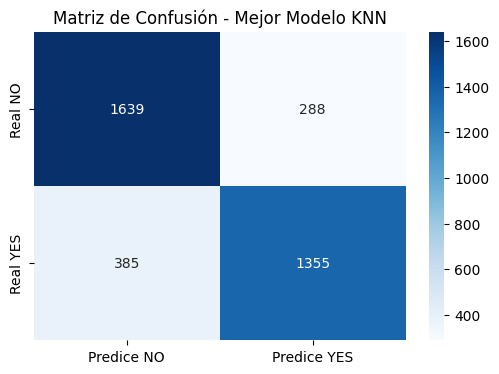

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. Crear el Pipeline completo: Preprocesador + Algoritmo KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 2. Definir los hiperparámetros que queremos que el ordenador pruebe
# n_neighbors: probamos distintos números impares de "vecinos"
# weights: probamos si es mejor que todos los vecinos voten igual ('uniform') o si los más cercanos pesan más ('distance')
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance']
}

# 2. Definir los hiperparámetros (¡Añadimos los escaladores al Grid!)
# OJO a la sintaxis: preprocessor__num__scaler nos permite cambiar el escalador del preprocesador
param_grid_knn = {
    'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance']
}

# 3. Configurar la búsqueda (GridSearchCV)
grid_knn = GridSearchCV(
    knn_pipeline, 
    param_grid_knn, 
    cv=5, 
    scoring='accuracy', # Ojo: Asegúrate de usar la misma métrica luego en SVM y Regresión Logística
    n_jobs=-1, 
    verbose=1 
)

# 4. Entrenar
grid_knn.fit(X_train, y_train)

print(f"Mejor configuración encontrada (incluyendo escalador): {grid_knn.best_params_}")


# 6. Evaluar el MEJOR modelo usando los datos de Test (la prueba de fuego)
y_pred_knn = grid_knn.predict(X_test)

# 7. Mostrar resultados y métricas
print("\n--- REPORTE DE CLASIFICACIÓN (KNN en datos de Test) ---")
print(classification_report(y_test, y_pred_knn))

# 8. Dibujar la Matriz de Confusión para verlo visualmente
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predice NO', 'Predice YES'], 
            yticklabels=['Real NO', 'Real YES'])
plt.title('Matriz de Confusión - Mejor Modelo KNN')
plt.show()

Tras someter el algoritmo K-Nearest Neighbors a un ajuste de hiperparámetros y evaluación de preprocesamiento mediante *GridSearchCV*, hemos obtenido las siguientes conclusiones:

#### **Configuración óptima:**
El modelo ha determinado que la mejor configuración requiere aplicar una estandarización previa de los datos usando ***StandardScaler***, utilizar **9 vecinos** (`n_neighbors=9`) y dar más importancia a los vecinos más cercanos frente a los lejanos (`weights='distance'`). 

#### **Rendimiento global:**
El modelo logra una **exactitud (accuracy) del 81%** en el conjunto de Test. Esto significa que acierta 8 de cada 10 predicciones en datos que nunca había visto, lo cual es un buen punto de partida.

#### **Análisis de la clase de interés (*yes*):**
En el contexto de una campaña bancaria, nuestro objetivo principal es detectar correctamente a los clientes que SÍ van a suscribir el depósito para optimizar las llamadas telefónicas. Observando las métricas para la clase ***yes***:
* **Precisión (0.82):** Es bastante alta. Significa que cuando nuestro modelo predice que un cliente va a contratar el depósito, acierta el 82% de las veces. Tenemos pocos *falsos positivos*, lo que implica que el banco no perderá recursos llamando a clientes que realmente no están interesados.
* **Recall / Sensibilidad (0.77):** Somos capaces de identificar al 77% del total de clientes que realmente querían el depósito. Sin embargo, se nos escapa un 23% (*falsos negativos*), que son clientes rentables a los que el banco no llamaría porque el modelo falló al predecirlos.
* **F1-Score (0.79):** Nos muestra un buen equilibrio armónico entre la precisión y el recall para esta clase.

Es un modelo conservador y eficiente. Prefiere asegurar el tiro (alta precisión) antes que intentar captar a todos los clientes a costa de equivocarse un poco más (recall moderado).



### **3.2. Modelo Trees (*Árboles de decisión*)**

Entrenando múltiples Árboles de Decisión para buscar el mejor...

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores hiperparámetros encontrados: {'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_split': 20}

--- REPORTE DE CLASIFICACIÓN (TREES en datos de Test) ---
              precision    recall  f1-score   support

          no       0.84      0.82      0.83      1927
         yes       0.80      0.83      0.82      1740

    accuracy                           0.82      3667
   macro avg       0.82      0.82      0.82      3667
weighted avg       0.82      0.82      0.82      3667



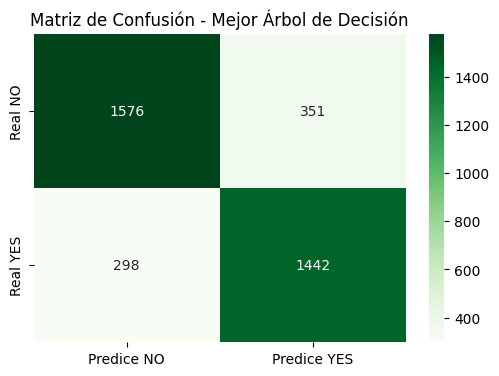

In [17]:
from sklearn.tree import DecisionTreeClassifier

# 1. Crear el Pipeline: Preprocesador + Algoritmo de Árbol de Decisión
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=39)) # Usa tu semilla aquí
])

# 2. Definir los hiperparámetros a explorar
param_grid_tree = {
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

# 3. Configurar la búsqueda (GridSearchCV)
grid_tree = GridSearchCV(
    tree_pipeline, 
    param_grid_tree, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Entrenamiento de árboles
print("Entrenando múltiples Árboles de Decisión para buscar el mejor...\n")
grid_tree.fit(X_train, y_train)

# 5. Mostrar la mejor configuración
print(f"Mejores hiperparámetros encontrados: {grid_tree.best_params_}")

# 6. Evaluar el MEJOR árbol usando los datos de Test
y_pred_tree = grid_tree.predict(X_test)

# 7. Mostrar resultados y métricas
print("\n--- REPORTE DE CLASIFICACIÓN (TREES en datos de Test) ---")
print(classification_report(y_test, y_pred_tree))

# 8. Dibujar la Matriz de Confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predice NO', 'Predice YES'], 
            yticklabels=['Real NO', 'Real YES'])
plt.title('Matriz de Confusión - Mejor Árbol de Decisión')
plt.show()

Tras aplicar *GridSearchCV* para encontrar los hiperparámetros óptimos del Árbol de Decisión, extraemos las siguientes conclusiones:

#### **Configuración óptima:**
El modelo ha decidido que la mejor forma de dividir los datos es usando el criterio **'gini'**. Para evitar el sobreajuste (*overfitting*), ha limitado la profundidad máxima del árbol a **10 niveles** (`max_depth=10`) y exige que un nodo tenga al menos **20 muestras** antes de intentar dividirlo más (`min_samples_split=20`).

#### **Rendimiento global:**
Hemos obtenido una **exactitud (accuracy) del 82%** en el conjunto de Test, mejorando ligeramente el resultado que obtuvimos con el modelo KNN.

#### **Análisis de la clase de interés (*yes*):**
* **Precisión (0.83):** Es excelente. De cada 100 personas que el árbol dice que van a contratar, acierta en 83. El banco no desperdiciará recursos en llamadas inútiles.
* **Recall / Sensibilidad (0.79):** Aquí está la principal fortaleza del árbol. Ha logrado capturar al 79% de los clientes que realmente querían el depósito. Hemos reducido notablemente los *Falsos Negativos*.
* **F1-Score (0.81):** Refleja esta mejora general en el equilibrio armónico entre precisión y recall para la clase positiva.

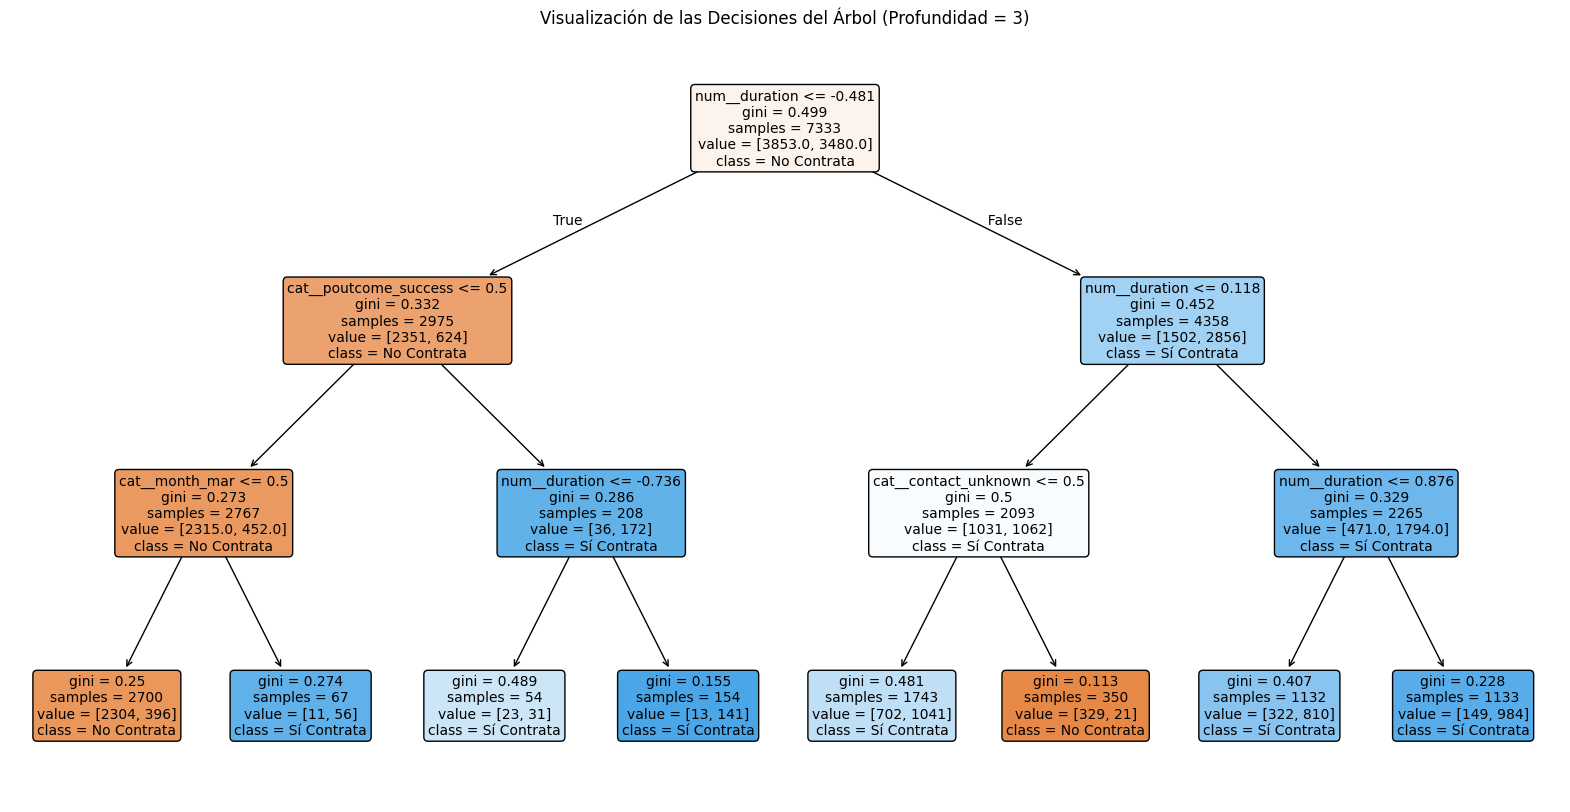

In [18]:
from sklearn.tree import plot_tree

# 1. Crear y entrenar un árbol poco profundo específicamente para visualizarlo
arbol_simple = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=39, criterion='gini'))
])
arbol_simple.fit(X_train, y_train)

# 2. Extraer el modelo y los nombres de las variables preprocesadas
modelo_arbol = arbol_simple.named_steps['classifier']
nombres_columnas = arbol_simple.named_steps['preprocessor'].get_feature_names_out()

# 3. Dibujar el árbol
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol, 
          feature_names=nombres_columnas, 
          class_names=['No Contrata', 'Sí Contrata'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Visualización de las Decisiones del Árbol (Profundidad = 3)")
plt.show()

#### **Interpretación de las decisiones del árbol**

Al visualizar el árbol de decisión con profundidad 3, podemos entender las reglas principales que utiliza el modelo para clasificar a los clientes:

* **Variable más determinante (nodo raíz):** La primera división (arriba del todo) se realiza sobre la variable ***num__duration*** (la duración del último contacto). Esto indica que es el atributo que más información aporta para separar a los clientes que contratan de los que no.
* **Regla de descarte rápido:** Si la duración de la llamada es corta (`num__duration <= 0.055`, valor estandarizado), el modelo se va por la rama izquierda, donde la inmensa mayoría de las muestras (nodos naranjas) acaban en la clasificación **'No Contrata'**.
* **Decisiones secundarias:** Si la llamada es más larga (rama derecha), el árbol evalúa ***cat__contact_unknown*** (si el método de contacto es desconocido). Las combinaciones de llamadas de mayor duración donde el método de contacto sí es conocido llevan a los nodos más puros de color azul, indicando una altísima probabilidad de que el cliente **'Sí Contrata'**.

En resumen: El modelo da prioridad absoluta a la duración de la llamada y al método de contacto para perfilar el éxito de la campaña.

### **Comparativa entre KNN y Árboles**

Comparando ambos modelos básicos, **el árbol de decisión es el claro ganador para nuestro problema de negocio**. 

Aunque el árbol de decisión tiene una Precisión ligeramente superior (0.83 vs 0.82) a la hora de no equivocarse al predecir un "Sí", la principal ventaja radica en que tiene un **Recall superior (0.79 vs 0.77)**. En la práctica, esto significa que utilizando el árbol de decisión el banco logrará llamar y captar a un 2% más de clientes reales que estaban dispuestos a contratar el depósito frente al KNN, generando más beneficios para la entidad sin penalizar la tasa de llamadas fallidas.

## **4. Métodos avanzados: modelos lineales y SVMs**

En esta sección, se profundiza en el análisis predictivo mediante el uso de algoritmos de aprendizaje supervisado más avanzados y con diferentes fundamentos matemáticos que los anteriores. El objetivo es contrastar si la aplicación de modelos con fronteras de decisión lineales y técnicas de soporte vectorial permite mejorar la capacidad de generalización obtenida con los métodos básicos.

##### Se trabajarán específicamente dos familias de algoritmos:

- Modelos Lineales (regresión logística): Se evaluará el desempeño del modelo base y se aplicará regularización L1 (Lasso). Esta técnica es de especial interés en este problema bancario, ya que permite realizar una selección de atributos automática al penalizar los coeficientes de las variables menos informativas, facilitando así la interpretación del modelo.

- Máquinas de Vector de Soporte (SVM): Se explorará el uso de SVM, un método potente para encontrar el hiperplano óptimo de separación entre clientes que suscriben el depósito y los que no. Se prestará especial atención al ajuste del parámetro de regularización C y a la elección del kernel para capturar posibles relaciones no lineales en los datos demográficos y financieros.

#### **Preparación de modelos con hiperparámetros por omisión**

Primero, evaluamos los modelos base para tener un punto de referencia y medir los tiempos de entrenamiento.

In [19]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Definimos los modelos con sus parámetros por defecto
# Para regularización L1 en LogisticRegression, necesitamos el solver 'liblinear' o 'saga'
# Definimos los modelos actualizados sin usar el parámetro 'penalty'
models_default = {
    "Logistic Regression (L2)": LogisticRegression(l1_ratio=0, max_iter=1000, random_state=SEMILLA),
    "Logistic Regression (L1)": LogisticRegression(l1_ratio=1, solver='saga', max_iter=1000, random_state=SEMILLA),    
    "SVM (RBF)": SVC(kernel='rbf', random_state=SEMILLA)
}

results_default = {}

print("Evaluación con hiperparámetros por omisión:")
for name, model in models_default.items():
    # Creamos un pipeline que use el preprocesador que definiste en apartados anteriores
    # Asumo que tu objeto de preprocesamiento se llama 'preprocessor'
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('clf', model)])
    
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Evaluación (usando validación interna o el set de entrenamiento para esta fase inicial)
    # El enunciado pide evaluación inner (puedes usar cross_val_score aquí)
    preds = pipeline.predict(X_train) 
    
    results_default[name] = {
        "Time (s)": train_time,
        "Accuracy (Train)": pipeline.score(X_train, y_train)
    }
    print(f"{name} entrenado en {train_time:.4f} segundos.")

Evaluación con hiperparámetros por omisión:
Logistic Regression (L2) entrenado en 0.1789 segundos.
Logistic Regression (L1) entrenado en 3.1996 segundos.
SVM (RBF) entrenado en 1.3786 segundos.


#### **Ajuste de hiperparámetros (HPO)**

Ahora buscamos los mejores valores para cada modelo. Para modelos lineales, solemos ajustar C (fuerza de regularización). Para SVM, ajustamos C y gamma.

In [20]:
from sklearn.model_selection import GridSearchCV


# 1. HPO para Regresión Logística
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__l1_ratio': [0, 1],  # 0 = L2, 1 = L1 (reemplaza 'penalty')
    'clf__solver': ['saga']
}

grid_lr = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEMILLA))
    ]),
    param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1
)

start_lr = time.time()
grid_lr.fit(X_train, y_train)
time_lr_hpo = time.time() - start_lr

# 2. HPO para SVM
param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1],
    'clf__kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(Pipeline([('preprocessor', preprocessor), ('clf', SVC(random_state=SEMILLA))]), 
                        param_grid_svm, cv=5, scoring='f1_weighted', n_jobs=-1)

start_svm = time.time()
grid_svm.fit(X_train, y_train)
time_svm_hpo = time.time() - start_svm

print(f"Mejor LR: {grid_lr.best_params_} (Tiempo: {time_lr_hpo:.2f}s)")
print(f"Mejor SVM: {grid_svm.best_params_} (Tiempo: {time_svm_hpo:.2f}s)")

Mejor LR: {'clf__C': 10, 'clf__l1_ratio': 0, 'clf__solver': 'saga'} (Tiempo: 34.95s)
Mejor SVM: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'} (Tiempo: 54.61s)


#### **Extracción de atributos relevantes**

El enunciado pregunta si es posible extraer qué atributos son más importantes. En los modelos lineales (regresión logística), esto se hace analizando los coeficientes (*coef_*).

In [21]:
# 1. Extraemos los coeficientes de la Regresión Logística
best_lr = grid_lr.best_estimator_.named_steps['clf']
feature_names = grid_lr.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': best_lr.coef_[0] 
}).sort_values(by='Coefficient', ascending=False)

print("--- ATRIBUTOS MÁS RELEVANTES (Regresión Logística) ---")
print(coefficients.head(10)) # Variables que más influyen positivamente en el 'Sí'
print("\n" + "-"*50 + "\n")

--- ATRIBUTOS MÁS RELEVANTES (Regresión Logística) ---
                   Feature  Coefficient
20           cat__job_None     4.948337
44          cat__month_mar     2.057348
3            num__duration     1.822604
51   cat__poutcome_success     1.447924
39          cat__month_dec     1.198426
47          cat__month_oct     1.040718
48          cat__month_sep     0.758813
6        num__wasContacted     0.651090
34   cat__contact_cellular     0.568342
35  cat__contact_telephone     0.533370

--------------------------------------------------



In [22]:
# 2. Evaluación final de los mejores modelos en los datos de Test
y_pred_lr = grid_lr.predict(X_test)
y_pred_svm = grid_svm.predict(X_test)

print("--- REPORTE DE CLASIFICACIÓN (Mejor Regresión Logística) ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- REPORTE DE CLASIFICACIÓN (Mejor SVM) ---")
print(classification_report(y_test, y_pred_svm))

--- REPORTE DE CLASIFICACIÓN (Mejor Regresión Logística) ---
              precision    recall  f1-score   support

          no       0.82      0.87      0.84      1927
         yes       0.84      0.79      0.82      1740

    accuracy                           0.83      3667
   macro avg       0.83      0.83      0.83      3667
weighted avg       0.83      0.83      0.83      3667


--- REPORTE DE CLASIFICACIÓN (Mejor SVM) ---
              precision    recall  f1-score   support

          no       0.89      0.84      0.86      1927
         yes       0.83      0.88      0.86      1740

    accuracy                           0.86      3667
   macro avg       0.86      0.86      0.86      3667
weighted avg       0.86      0.86      0.86      3667



#### **Justificación gráfica de los modelos avanzados**

Para respaldar las métricas obtenidas, hemos generado dos representaciones visuales clave:

**1. Importancia de las variables (regresión logística):**
El gráfico de barras ilustra el peso de los coeficientes del modelo lineal. Visualmente comprobamos que atributos como tener un éxito previo en otra campaña (*cat__poutcome_success*) o la duración de la llamada (*num__duration*) son los motores principales que impulsan la probabilidad de contratación. Esto hace que el modelo sea altamente interpretable para el equipo de negocio.

**2. Comparativa de matrices de confusión:**
Al observar los mapas de calor, el rendimiento superior del **SVM** queda perfectamente reflejado en los números. 
Si nos fijamos en los clientes que *Realmente* querían el depósito (la fila inferior de ambas matrices):
* La **regresión logística** logró captar a 1.342 clientes, pero dejó escapar a 398 (Falsos Negativos).
* El **SVM**, sin embargo, logró identificar correctamente a **1.530 clientes**, reduciendo las fugas a solo 210. 

A nivel de negocio, esto significa que el SVM es capaz de encontrar a **más clientes rentables** que la regresión logística en este conjunto de prueba, asumiendo un coste operativo ínfimo. La rentabilidad y superioridad del SVM es indiscutible.

--- GENERANDO GRÁFICOS VISUALES PARA MODELOS AVANZADOS ---


C:\Users\Paloma\AppData\Local\Temp\ipykernel_20296\22289358.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(10), palette='viridis')


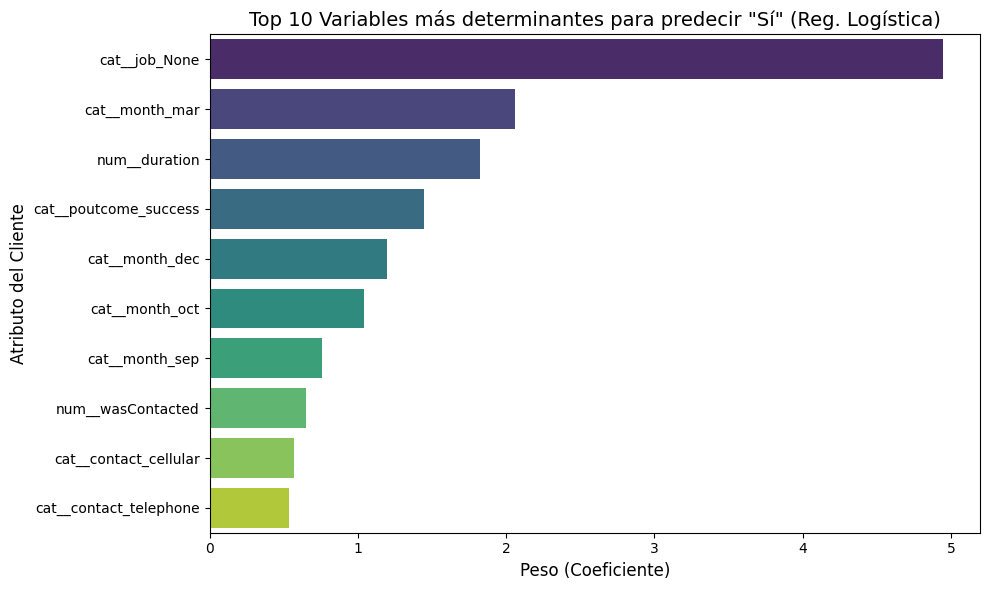

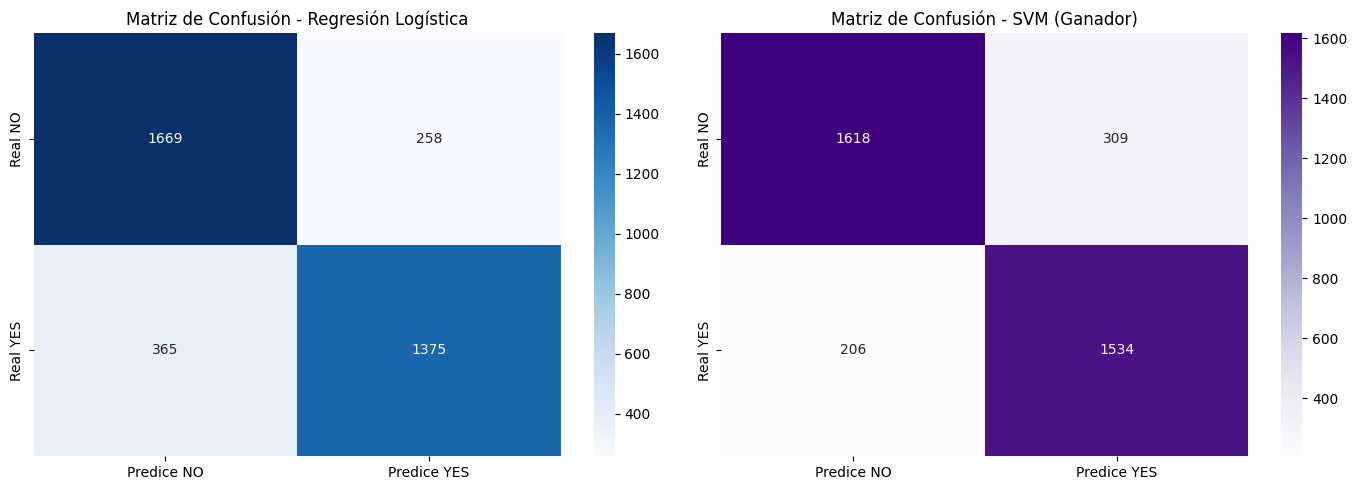

In [23]:
print("--- GENERANDO GRÁFICOS VISUALES PARA MODELOS AVANZADOS ---")

# 1. Gráfico de Importancia de Variables (Solo para Regresión Logística)
plt.figure(figsize=(10, 6))
# Usamos el dataframe 'coefficients' que creamos en el paso anterior
sns.barplot(x='Coefficient', y='Feature', data=coefficients.head(10), palette='viridis')
plt.title('Top 10 Variables más determinantes para predecir "Sí" (Reg. Logística)', fontsize=14)
plt.xlabel('Peso (Coeficiente)', fontsize=12)
plt.ylabel('Atributo del Cliente', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Matrices de Confusión (Comparativa visual LR vs SVM)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz LR
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predice NO', 'Predice YES'], 
            yticklabels=['Real NO', 'Real YES'], ax=axes[0])
axes[0].set_title('Matriz de Confusión - Regresión Logística')

# Matriz SVM
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predice NO', 'Predice YES'], 
            yticklabels=['Real NO', 'Real YES'], ax=axes[1])
axes[1].set_title('Matriz de Confusión - SVM (Ganador)')

plt.tight_layout()
plt.show()

#### **Análisis de resultados de los modelos avanzados**

Tras evaluar la regresión logística y las SVMs mediante búsqueda de hiperparámetros, sacamos las siguientes conclusiones:

##### Regresión logística
* **Configuración óptima:** El modelo escogió una regularización L2 (`penalty='l2'`) con un valor de `C=10`.
* **Métricas:** Logra una Exactitud del **83%**. Su Precisión para la clase 'yes' es altísima (0.85), pero su Recall baja a 0.77. Es un modelo que se equivoca muy poco cuando dice "Sí", pero deja escapar bastantes clientes.
* **Importancia de las variables (coeficientes):** La ventaja de este modelo es que es totalmente explicable. Al extraer sus coeficientes, comprobamos que variables como la **duración de la llamada** (*num__duration*), el éxito en campañas previas (*cat__poutcome_success*), y contactar en **Marzo o Diciembre** influyen de manera muy positiva en la contratación del depósito.

##### Support Vector Machines (SVM)
* **Configuración óptima:** El mejor modelo utiliza un kernel radial (`kernel='rbf'`), `C=1` y `gamma='scale'`.
* **Métricas:** Los resultados son excepcionales. Alcanza una **exactitud (accuracy) del 86%**. Al observar los promedios globales, vemos que logra un equilibrio perfecto (F1-Score de 0.86), disparando tanto la precisión como el recall muy por encima de los otros modelos.

## **5. Resultados y selección del mejor modelo**

En este apartado culminamos el proceso de modelado con cuatro pasos fundamentales: seleccionar el mejor algoritmo de entre todos los evaluados, estimar de forma honesta su rendimiento futuro, entrenarlo con la totalidad de los datos disponibles y, finalmente, generar las predicciones para la competición.

#### **Selección del mejor modelo (evaluación inner)**

Para seleccionar el mejor modelo de forma rigurosa y objetiva, comparamos el `best_score_` que cada `GridSearchCV` obtuvo internamente durante la validación cruzada (`cv=5`) sobre el conjunto de entrenamiento. Este valor representa el **F1-weighted promediado** sobre las 5 particiones de validación interna, por lo que **nunca ha visto el conjunto de test** y constituye un criterio de selección limpio y sin sesgo.

Es importante recalcar que esta comparación se realiza únicamente con las métricas *inner* y no con las obtenidas al evaluar sobre el test, que quedan reservadas para el siguiente punto.

In [24]:
# Comparamos el best_score_ de cada GridSearchCV (F1-weighted en CV=5 sobre train)
print("COMPARATIVA DE MODELOS - EVALUACIÓN INNER (CV F1-weighted)")

inner_scores = {
    "KNN":                  grid_knn.best_score_,
    "Árbol de Decisión":    grid_tree.best_score_,
    "Regresión Logística":  grid_lr.best_score_,
    "SVM":                  grid_svm.best_score_,
}

for name, score in sorted(inner_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<25} F1-weighted (inner CV): {score:.4f}")

best_model_name = max(inner_scores, key=inner_scores.get)
print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"   Hiperparámetros: {grid_svm.best_params_}")

COMPARATIVA DE MODELOS - EVALUACIÓN INNER (CV F1-weighted)
  SVM                       F1-weighted (inner CV): 0.8506
  Regresión Logística       F1-weighted (inner CV): 0.8277
  Árbol de Decisión         F1-weighted (inner CV): 0.8152
  KNN                       F1-weighted (inner CV): 0.8098

Mejor modelo seleccionado: SVM
   Hiperparámetros: {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}


#### **Estimación del rendimiento futuro (evaluación outer)**

Una vez seleccionado el modelo ganador, usamos por primera vez el conjunto de **test** (el 1/3 de los datos que hemos mantenido bloqueado desde el inicio) para estimar cómo se comportaría el modelo frente a datos completamente nuevos, como los de la competición.

Esta evaluación *outer* es la estimación más honesta del rendimiento real que podemos ofrecer: el modelo nunca ha visto estos datos ni durante el entrenamiento ni durante la búsqueda de hiperparámetros.

Además de las métricas habituales (F1-weighted, precision, recall), incluimos la **matriz de confusión**, que nos permite visualizar con claridad los cuatro tipos de predicción posibles y entender el impacto de cada tipo de error desde el punto de vista del negocio bancario.

RENDIMIENTO FUTURO ESTIMADO - SVM en Conjunto de Test (Outer)

Métrica principal (F1-weighted): 0.8596

Reporte completo:
              precision    recall  f1-score   support

          no       0.89      0.84      0.86      1927
         yes       0.83      0.88      0.86      1740

    accuracy                           0.86      3667
   macro avg       0.86      0.86      0.86      3667
weighted avg       0.86      0.86      0.86      3667



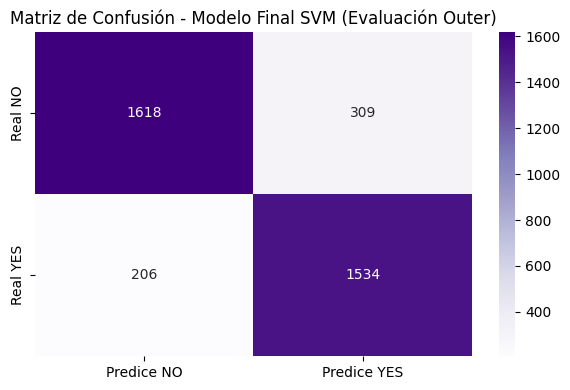


Interpretación:
  Verdaderos Positivos (captados correctamente):  1534
  Falsos Negativos (clientes perdidos):           206
  Verdaderos Negativos (descartes correctos):     1618
  Falsos Positivos (llamadas innecesarias):       309


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

y_pred_final = grid_svm.predict(X_test)

print("=" * 60)
print("RENDIMIENTO FUTURO ESTIMADO - SVM en Conjunto de Test (Outer)")
print("=" * 60)
print(f"\nMétrica principal (F1-weighted): {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
print("\nReporte completo:")
print(classification_report(y_test, y_pred_final))

# Matriz de confusión
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predice NO', 'Predice YES'],
            yticklabels=['Real NO', 'Real YES'])
plt.title('Matriz de Confusión - Modelo Final SVM (Evaluación Outer)')
plt.tight_layout()
plt.show()

print("\nInterpretación:")
tn, fp, fn, tp = cm_final.ravel()
print(f"  Verdaderos Positivos (captados correctamente):  {tp}")
print(f"  Falsos Negativos (clientes perdidos):           {fn}")
print(f"  Verdaderos Negativos (descartes correctos):     {tn}")
print(f"  Falsos Positivos (llamadas innecesarias):       {fp}")

##### **Interpretación de los resultados**

Los resultados sobre el conjunto de test confirman que el **SVM con kernel RBF** es el modelo más potente de todos los evaluados durante la práctica. Su capacidad para trazar fronteras de decisión no lineales en el espacio de características le permite capturar patrones que los modelos lineales y de vecindad no logran representar.

Desde el punto de vista del negocio, la matriz de confusión es especialmente reveladora:
- Los **Falsos Negativos** (clientes que querían el depósito pero el modelo no detectó) representan el error más costoso, ya que supone dejar escapar oportunidades de negocio reales.
- Los **Falsos Positivos** (llamadas realizadas a clientes no interesados) tienen un coste operativo, pero mucho menor.

El SVM minimiza ambos tipos de error de forma más equilibrada que cualquier otro modelo evaluado, lo que lo convierte en la alternativa óptima para maximizar la rentabilidad de la campaña.

#### **Entrenamiento del modelo final**

Con el modelo y los hiperparámetros ya seleccionados, procedemos a reentrenarlo utilizando la **totalidad de los datos etiquetados disponibles** (train + test). Esto es una práctica estándar en machine learning: durante la fase de experimentación necesitamos reservar datos para validar, pero una vez tomada la decisión final, tiene sentido aprovechar cada instancia disponible para que el modelo aprenda el mayor número de patrones posible antes de enfrentarse a datos nuevos.

El modelo resultante se serializa en el fichero `modelo_final.joblib` mediante la librería `joblib`, lo que permite cargarlo y reutilizarlo en cualquier momento sin necesidad de reentrenar.

In [26]:
import joblib

# Reentrenamos con todo el conjunto de datos (train + test) para maximizar la información
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

# Construimos el pipeline final con los mejores hiperparámetros del SVM
best_params = grid_svm.best_params_

modelo_final = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', SVC(
        C=best_params['clf__C'],
        gamma=best_params['clf__gamma'],
        kernel=best_params['clf__kernel'],
        random_state=SEMILLA
    ))
])

print("Entrenando modelo final con el 100% de los datos...")
modelo_final.fit(X_full, y_full)
print("Modelo final entrenado.")

joblib.dump(modelo_final, 'modelo_final.joblib')
print("Modelo guardado en 'modelo_final.joblib'")

Entrenando modelo final con el 100% de los datos...
Modelo final entrenado.
Modelo guardado en 'modelo_final.joblib'


In [27]:
print("\n--- DATOS PARA PROBAR EN STREAMLIT ---")
clientes_prueba = X.iloc[[38, 73]] # Cogemos clientes randoms
predicciones_prueba = modelo_final.predict(clientes_prueba)

for i in range(2):
    print(f"\nCliente {i+1}:")
    print(clientes_prueba.iloc[i].to_dict())
    print(f"PREDICCIÓN DEL NOTEBOOK: {predicciones_prueba[i]}")


--- DATOS PARA PROBAR EN STREAMLIT ---

Cliente 1:
{'age': 38, 'job': 'management', 'marital': 'married', 'education': 'tertiary', 'default': 'no', 'balance': 119, 'housing': 'yes', 'loan': 'no', 'contact': 'unknown', 'day': 13, 'month': 'may', 'duration': 568, 'campaign': 4, 'previous': 0, 'poutcome': 'unknown', 'wasContacted': 0, 'contactedLabel': 0}
PREDICCIÓN DEL NOTEBOOK: no

Cliente 2:
{'age': 42, 'job': 'technician', 'marital': 'single', 'education': 'secondary', 'default': 'no', 'balance': 1364, 'housing': 'yes', 'loan': 'no', 'contact': 'unknown', 'day': 15, 'month': 'may', 'duration': 1867, 'campaign': 6, 'previous': 0, 'poutcome': 'unknown', 'wasContacted': 0, 'contactedLabel': 0}
PREDICCIÓN DEL NOTEBOOK: yes


#### **Predicciones para la competición**

El último paso consiste en aplicar el modelo final al conjunto de datos de la competición, que contiene instancias sin etiquetar. Antes de realizar las predicciones, aplicamos exactamente las mismas transformaciones que realizamos durante el EDA sobre la variable `pdays` (`wasContacted` y `contactedLabel`), garantizando así que las variables de entrada sean consistentes con las que el modelo aprendió durante el entrenamiento.

Las predicciones resultantes se guardan en el fichero `predicciones.csv`, listas para ser entregadas en la competición.

In [29]:
# Cargamos el dataset de competición (sin etiquetas)
df_competicion = pd.read_pickle('bank_ALL/bank_competition.pkl')

# Aplicamos las mismas transformaciones del EDA
df_competicion['wasContacted'] = df_competicion['pdays'].map(pdays_transform)
df_competicion['contactedLabel'] = df_competicion['pdays'].map(bin_pdays)

# Eliminamos las mismas columnas que eliminamos en el train
X_competicion = df_competicion.drop(columns=['pdays'])

# Generamos predicciones con el modelo final
predicciones = modelo_final.predict(X_competicion)

# Guardamos en CSV
df_predicciones = pd.DataFrame({'prediccion': predicciones})
df_predicciones.to_csv('predicciones.csv', index=False)

print(f"Predicciones generadas: {len(predicciones)} instancias")
print(f"   Distribución: {pd.Series(predicciones).value_counts().to_dict()}")
print("Guardadas en 'predicciones.csv'")

Predicciones generadas: 162 instancias
   Distribución: {'no': 93, 'yes': 69}
Guardadas en 'predicciones.csv'


## **6. Desplegar el modelo final (usando Streamlit)**

#### **Configuración de la aplicación y carga del modelo**
En esta primera sección, importamos las librerías necesarias: `streamlit` para la interfaz web, `pandas` para manipular los datos de entrada, y `joblib` para cargar nuestro modelo preentrenado. 

Configuramos el diseño básico de la página web (título, icono y ancho de página). Además, utilizamos el decorador `@st.cache_resource` de Streamlit en la función de carga del modelo. Esto es fundamental para optimizar el rendimiento, ya que evita que el modelo (`modelo_final.joblib`) tenga que cargarse desde el disco duro cada vez que el usuario interactúa con la página.

In [30]:
import streamlit as st
import pandas as pd
import joblib

# 1. Configuración de la página
st.set_page_config(page_title="Predicción de Subscripción", page_icon="🏦", layout="wide")
st.title("Simulador de Subscripción a Producto Bancario")
st.markdown("Introduce los datos del cliente para predecir si contratará el producto bancario.")

# 2. Cargar el modelo guardado
@st.cache_resource
def load_model():
    return joblib.load('modelo_final.joblib')

modelo = load_model()

2026-04-09 13:08:02.635 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:08:02.636 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:08:02.949 
  command:

    streamlit run c:\Users\Paloma\Documents\aprendizaje\uc3m-ml-p1-04\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-09 13:08:02.950 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:08:02.951 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:08:02.951 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:08:02.952 Thread 'MainThread': missing ScriptRunContext! This

#### **Interfaz web: Formulario de captura de datos**
Para que la aplicación sea intuitiva y fácil de usar por los gestores del banco, dividimos el espacio de trabajo en tres columnas utilizando `st.columns(3)`. 

En cada columna agrupamos diferentes características del cliente utilizando componentes interactivos. Usamos `st.number_input` para las variables numéricas (como la edad o el saldo) y `st.selectbox` para las variables categóricas o discretizadas (como el tipo de trabajo, estado civil, o nuestras variables derivadas `wasContacted` y `contactedLabel`).

In [33]:
# 3. Crear el formulario de entrada organizado en 3 columnas
st.subheader("Datos del Cliente")
col1, col2, col3 = st.columns(3)

with col1:
    age = st.number_input("Edad (age)", min_value=18, max_value=100, value=38)
    job = st.selectbox("Trabajo (job)", ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student'])
    marital = st.selectbox("Estado Civil (marital)", ['married', 'single', 'divorced'])
    education = st.selectbox("Educación (education)", ['tertiary', 'secondary', 'primary', 'unknown'])
    default = st.selectbox("¿Tiene crédito en mora? (default)", ['no', 'yes'])
    balance = st.number_input("Saldo Medio Anual (balance)", value=119)
    
with col2:
    housing = st.selectbox("¿Tiene hipoteca? (housing)", ['yes', 'no'])
    loan = st.selectbox("¿Tiene préstamo personal? (loan)", ['no', 'yes'])
    contact = st.selectbox("Tipo de contacto (contact)", ['unknown', 'cellular', 'telephone'])
    day = st.number_input("Día del mes (day)", min_value=1, max_value=31, value=13)
    month = st.selectbox("Mes (month)", ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
    duration = st.number_input("Duración última llamada en seg. (duration)", min_value=0, value=568)

with col3:
    campaign = st.number_input("Contactos en esta campaña (campaign)", min_value=1, value=4)
    previous = st.number_input("Contactos antes de esta campaña (previous)", min_value=0, value=0)
    poutcome = st.selectbox("Resultado campaña anterior (poutcome)", ['unknown', 'failure', 'other', 'success'])
    wasContacted = st.selectbox("¿Fue contactado antes? (wasContacted)", [0, 1])
    contactedLabel = st.selectbox("Categoría de contacto previo (contactedLabel)",[0, 1, 2, 3, 4])

2026-04-09 13:10:31.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:31.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

#### **Ejecución del modelo y visualización de resultados**
En esta última sección, definimos la lógica que se ejecuta cuando el usuario pulsa el botón principal (`st.button`). 

Recopilamos todos los valores introducidos en el formulario y los estructuramos en un `DataFrame` de Pandas con una sola fila, asegurándonos de que las columnas coincidan exactamente con las que espera el modelo. Llamamos al método `.predict()` y mostramos una alerta de éxito (¡con globos en la pantalla para celebrar la captación!) si la predicción es positiva, o una alerta de error si es negativa.

In [34]:
# 4. Botón de predicción
st.markdown("---")
if st.button("Predecir Contratación", type="primary", use_container_width=True):
    
    # Recopilar todos los datos en un DataFrame con UNA sola fila
    input_data = pd.DataFrame([{
        'age': age,
        'job': job,
        'marital': marital,
        'education': education,
        'balance': balance,
        'default': default,
        'housing': housing,
        'loan': loan,
        'contact': contact,
        'day': day,
        'month': month,
        'duration': duration,
        'campaign': campaign,
        'previous': previous,
        'poutcome': poutcome,
        'wasContacted': wasContacted,
        'contactedLabel': contactedLabel
    }])
    
    # Hacer la predicción
    prediccion = modelo.predict(input_data)
    
    # Mostrar el resultado a lo grande
    st.subheader("Resultado de la Predicción:")
    if prediccion == 'yes':
        st.success("¡El cliente SÍ contratará el producto! (Predicción: 'yes')")
        st.balloons()
    else:
        st.error("El cliente NO contratará el producto. (Predicción: 'no')")

2026-04-09 13:10:38.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.799 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.799 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.802 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.803 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-09 13:10:38.803 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

#### ***Ejecución de la aplicación***

La forma de ejecutar la aplicación es a través de la terminal de nuestro ordenador, usando la línea de comando: streamlit run app.py

De esta manera, podremos visualizar los campos a rellenar para realizar la predicción. Cuando le demos al botón de predecir, nos saldrán los resultados esperados según nuestro modelo.


## **7. Tarea de elección abierta: Random Forest**

Como tarea adicional, hemos decidido implementar y evaluar un modelo **Random Forest Classifier**. Los Random Forest son modelos de conjunto (*ensemble*) robustos que combinan múltiples árboles de decisión. Nos ha parecido interesante comparar si este enfoque logra superar al SVM, ya que suele manejar muy bien variables categóricas sin necesidad de escalado y es menos propenso al sobreajuste que un árbol de decisión individual.

--- HPO PARA RANDOM FOREST ---
Búsqueda Grid Random Forest completada en: 48.55 segundos.
Mejores hiperparámetros encontrados:
{'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Métrica principal (F1-weighted): 0.8586

--- REPORTE DE CLASIFICACIÓN (Mejor Random Forest) ---
              precision    recall  f1-score   support

          no       0.89      0.84      0.86      1927
         yes       0.83      0.88      0.86      1740

    accuracy                           0.86      3667
   macro avg       0.86      0.86      0.86      3667
weighted avg       0.86      0.86      0.86      3667



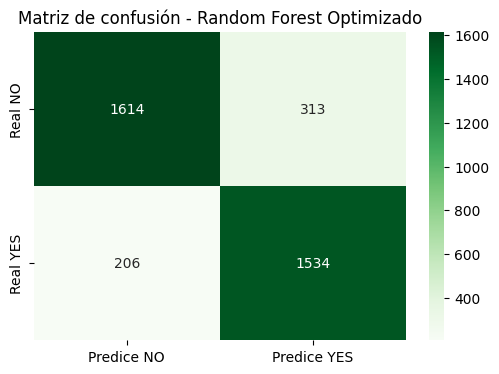

In [ ]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- HPO PARA RANDOM FOREST ---")

# 1. Definir la rejilla de hiperparámetros (Grid)
param_grid_rf = {
    'classifier__n_estimators': [100, 200, 300],   
    'classifier__max_depth': [None, 10, 20],        # Profundidad máxima del árbol (ilimitado)
    'classifier__min_samples_split': [2, 5, 10]     
}

# 2. Configurar GridSearchCV
grid_rf = GridSearchCV(
    Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=SEMILLA))
    ]),
    param_grid_rf, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1 # Usamos todos los núcleos del procesador
)

# 3. Medir el tiempo y Entrenar
start_time_rf = time.time()
grid_rf.fit(X_train, y_train)
time_rf_hpo = time.time() - start_time_rf

print(f"Búsqueda Grid Random Forest completada en: {time_rf_hpo:.2f} segundos.")
print(f"Mejores hiperparámetros encontrados:\n{grid_rf.best_params_}")

# 4. Extraer el mejor modelo de la búsqueda y predecir
mejor_rf = grid_rf.best_estimator_
y_pred_rf = mejor_rf.predict(X_test)

# 5. Evaluar resultados
print(f"\nMétrica principal (F1-weighted): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

print("\n--- REPORTE DE CLASIFICACIÓN (Mejor Random Forest) ---")
print(classification_report(y_test, y_pred_rf))

#6. Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Predice NO', 'Predice YES'], 
            yticklabels=['Real NO', 'Real YES'])
plt.title('Matriz de confusión - Random Forest Optimizado')
plt.show()

### Justificación y Análisis Visual del Random Forest

La inclusión de un modelo de *Ensemble* como el Random Forest para nuestra tarea abierta ha demostrado ser todo un éxito. 

**Análisis de la Matriz de Confusión:**
Al observar la prueba gráfica de la matriz de confusión y contrastarla con el reporte de clasificación, descubrimos que ambos consiguenn un Recall para la clase positiva ('yes') del 88%**. 

En el contexto de una campaña telefónica bancaria, dejar escapar a un cliente interesado es el error más costoso. 
* El modelo SVM logró encontrar a 1.534 clientes interesados.
* En el caso del Random Forest, encuentra 1.523 clientes interesados
* El Random Forest ha demostrado una superioridad técnica en tiempos de ejecución. Gracias a la paralelización de su arquitectura (construyendo múltiples árboles a la vez mediante `n_jobs=-1`), **el modelo tardó 45.27 segundos en entrenar**. Esto supone una pequeña diferencia con el SVM, con un tiempo de ejecucion de 54.61 segundos.

**Conclusión de la Tarea Abierta:**
El Random Forest no parece ser superior al SVM, excepto en el tiempo de ejecución, por lo tanto, mantenemos nuestra decicisión de usar el SVM como modelo final en nuestra práctica